In [199]:
import numpy as np
import matplotlib.pyplot as plt

# Set environment variables
import os


os.environ["SCAL_TYPE"] = "complex"
os.environ["PRECISION"] = "single"
os.environ["MY_NUMBA_TARGET"] = "numba"
 
 
# Add cle_fun to PYTHON_PATH
import sys
sys.path.append("../../clonscal")

In [200]:
errors = []
cl_estimate = []
angles = []
interaction = 1
sigma_abs = 5

start_angle = np.pi/4
stop_angle = np.pi

num = 4
angles = np.linspace(start_angle, stop_angle, num, endpoint=False)
sigma_vals = sigma_abs*(np.cos(angles) + 1j*np.sin(angles))

phi_singular = 5
pullback = 100


In [201]:
def abs_mod_drift(z, mass, interaction, z0, r):
    action = mass*z*z/2 + interaction*z**4/4
    action_0 = mass*z0**2/2 + interaction*z0**4/4

    unmod_drift =  mass*z + interaction*z*z*z

    num = unmod_drift*np.exp(-action)-2*r*z
    den = r*(z**2-z0**2) - np.exp(-action_0)+ np.exp(-action)
    return np.abs(num/den)

In [202]:
import numpy as np
from simulation.config import Config
from simulation.cl_simulation import ComplexLangevinSimulation
from src.obs_kernels import n_moment_kernel
from tqdm import tqdm
from simulation.gpu_handler import GPU_handler
from src.numba_target import use_cuda
import src.scal as scal
from sim_data.save_data import create_unique_file
from src.utils import quadratic_modified_density_drift_kernel

steps = int(5e4)
trajs = int(1e4)

for idx_sig, sigma in enumerate(sigma_vals):
    histograms = []
    edges_x = []
    edges_y = []
    print(sigma, interaction)
    label = rf"$Re (\sigma)={{{np.round(sigma.real, 2)}}} \quad Im (\sigma)={{{np.round(sigma.imag, 2)}}}$"
    config = Config(dt = 1e-2, trajs = trajs, dims = [1], mass_real = sigma, interaction = interaction, ada_step = True, drift_kernel=quadratic_modified_density_drift_kernel,
                    phi_singular=phi_singular, pullback=pullback)
    sim = ComplexLangevinSimulation(config)
    sim.register_observable('1_moment', obs_kernel=n_moment_kernel, const_param={'order': 1}, langevin_history=True, thermal_time=.1, auto_corr=0.1)

    # for _ in tqdm(range(int(2e4-1))):
    for _ in tqdm(range(steps)):
        sim.step()
        for name, tr in sim.trackers.items():
            tr.mark_equilibrated_trajs()
            
            tr.compute()
    sim.finish()
    data = (sim.trackers['1_moment'].history.flatten())

    magnitudes = np.abs(data)
    data = data[magnitudes<30]

    real_parts, imag_parts = data.real, data.imag
    bins = 500

    hist, x_edges, y_edges = np.histogram2d(real_parts, imag_parts, bins=bins)
    histograms.append(hist)
    edges_x.append(x_edges)
    edges_y.append(y_edges)

    # Save histograms and edges to a .npz file
    np.savez(f'sim_data/histogram_sigmaa{np.round(np.abs(sigma), 3)}_sigmap{np.round(np.angle(sigma), 3)}_lamba{np.abs(interaction)}_z0{phi_singular}_r{pullback}.npz', 
            histograms=np.array(histograms), 
            edges_x=np.array(edges_x), 
            edges_y=np.array(edges_y))

# data_full = np.array(data_full)
# name = create_unique_file(heatmaps, directory="../sim_data")

(3.5355339059327378+3.5355339059327373j) 1


100%|██████████| 50000/50000 [00:19<00:00, 2572.85it/s]


(0.9754516100806416+4.903926402016152j) 1


100%|██████████| 50000/50000 [00:19<00:00, 2612.99it/s]


(-1.9134171618254485+4.619397662556434j) 1


100%|██████████| 50000/50000 [00:18<00:00, 2632.60it/s]


(-4.157348061512726+2.777851165098011j) 1


100%|██████████| 50000/50000 [00:19<00:00, 2596.87it/s]


In [205]:
from scipy.integrate import solve_ivp
import numpy as np

def solve_floweq(flow_equation, crit_point, epsilon = 0.001, t_span = (0, 100), t_points=10, events = None, **kwargs):
    t_eval = np.linspace(t_span[0], t_span[1], t_points)
    sol = []
    directions_num = 2
    angles = np.linspace(0, 2*np.pi, directions_num, endpoint=False)
    perturbations = epsilon * np.exp(1j * angles)

    sigma = kwargs.get("sigma", 5*np.exp(1j*np.pi*3/4)) 
    lamb = kwargs.get("lamb", 1) 
    pullback = kwargs.get("pullback", 1) 
    phi_singular = kwargs.get("phi_singular", 5)

    for perturb in perturbations:
        z0 = crit_point + perturb
        z0 = [np.real(crit_point + perturb), np.imag(crit_point + perturb)]

        solution = solve_ivp(flow_equation, t_span, y0 = z0, args = (sigma, lamb, pullback, phi_singular), t_eval=t_eval, method="BDF")
        sol.append(solution.y[0] + 1j * solution.y[1])
    return sol


def drift_func(z, sigma, lamb, pullback, phi_singular):
    action_z = sigma/2*z**2+lamb/4*z**4
    action_z0 = sigma/2*phi_singular**2+lamb/4*phi_singular**4

    if np.real(action_z) < 200: 
        if np.real(action_z0) < 0:
            num = z*(lamb*z**2+sigma-2*pullback*np.exp(action_z))*np.exp(action_z0)
            den = np.exp(action_z+action_z0)*pullback*(z**2-phi_singular**2)-np.exp(action_z)+np.exp(action_z0)
            out= num/den
            return out
        
        if np.real(action_z0) > 0:
            num = z*(lamb*z**2+sigma-2*pullback*np.exp(action_z))
            den = np.exp(action_z)*pullback*(z**2-phi_singular**2)-np.exp(action_z-action_z0)+1
            out= num/den
            return out
        
    elif np.real(action_z) > np.log(np.abs((sigma+lamb*z**2)/pullback))+30:
        out = -2*pullback*z / (pullback*(z**2-phi_singular**2)+np.exp(-action_z)-np.exp(-action_z0))
        return out

    print('AUTSCH!')
    return np.inf

drift_func = np.vectorize(drift_func)


def flow_equation_stable(t, z, *kwargs):
    z_real, z_imag = z
    z_complex = z_real+1j*z_imag
    flow = np.conj(drift_func(z_complex, *kwargs))
    return [np.real(flow), np.imag(flow)]

def flow_equation_unstable(t, z, *kwargs):
    z_real, z_imag = z
    z_complex = z_real+1j*z_imag
    flow = -np.conj(drift_func(z_complex, *kwargs))
    return [np.real(flow), np.imag(flow)]


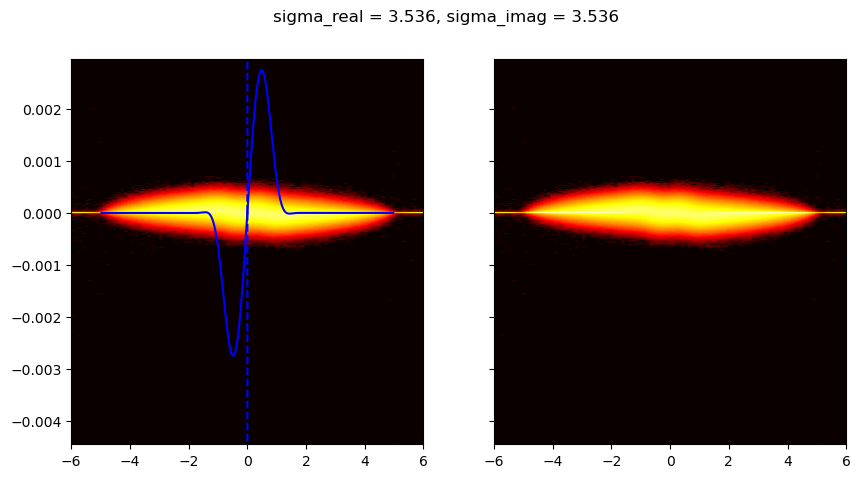

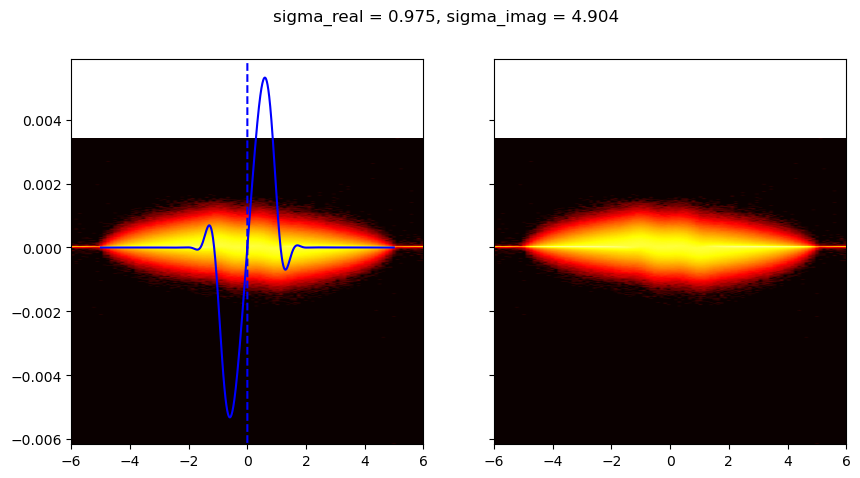

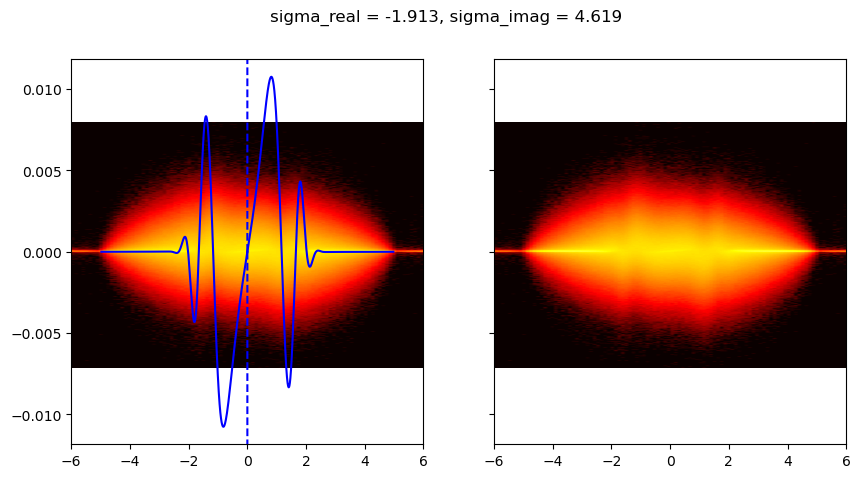

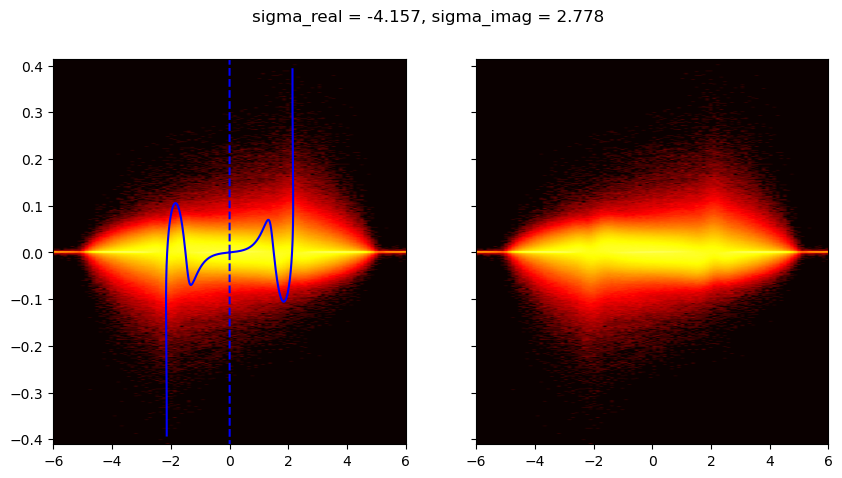

In [206]:
for idx_sig, sigma in enumerate(sigma_vals):
    fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

    file = f'sim_data/histogram_sigmaa{np.round(np.abs(sigma), 3)}_sigmap{np.round(np.angle(sigma), 3)}_lamba{np.abs(interaction)}_z0{phi_singular}_r{pullback}.npz'
    data = np.load(file)
    hist = data['histograms'][0]
    edges_x = data['edges_x'][0]
    edges_y = data['edges_y'][0]
    fig.suptitle(f"sigma_real = {np.round(np.real(sigma), 3)}, sigma_imag = {np.round(np.imag(sigma), 3)}")
    ax[0].imshow(
    np.log10(hist+1).T,extent=[edges_x[0], edges_x[-1], edges_y[0], edges_y[-1]],origin='lower',cmap='hot',aspect='auto',
    )

    ax[1].imshow(
    np.log10(hist+1).T,extent=[edges_x[0], edges_x[-1], edges_y[0], edges_y[-1]],origin='lower',cmap='hot',aspect='auto',
    )
    # Stable
    solutions = solve_floweq(flow_equation_stable, crit_point=0, t_span = (0, 500), t_points=1000000, sigma = sigma, lamb=interaction, pullback=pullback, phi_singular=phi_singular)
    for sol in solutions:
        ax[0].plot(sol.real, sol.imag, color = 'blue')  # Set transparency for better visibility
    ylim = ax[0].get_ylim()
    # unstabele
    solutions = solve_floweq(flow_equation_unstable, crit_point=0, t_span = (0, 500), t_points=1000000, sigma = sigma, lamb=interaction, pullback=pullback, phi_singular=phi_singular)
    for sol in solutions:
        ax[0].plot(sol.real, sol.imag, color = 'blue', ls = '--')  # Set transparency for better visibility
    
    ax[0].set_xlim(-6, 6)
    ax[0].set_ylim(*ylim)

In [ ]:
import matplotlib.pyplot as plt
fig1, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)


# fig1.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing between subplots

# for idx, (hist, sigma, ax) in enumerate(zip(histograms, sigma_vals, ax)):
sigma = sigma_vals[0]
hist = histograms[0]
label = rf"$Re (\sigma)={{{np.round(sigma.real, 2)}}} \, Im (\sigma)={{{np.round(sigma.imag, 2)}}}$"
xedg = edges_x[0]
yedg = edges_y[0]

# Plot the heatmap
ax[0].imshow(
    np.log10(hist+1).T,
    extent=[xedg[0], xedg[-1], yedg[0], yedg[-1]],
    origin='lower',
    cmap='hot',
    aspect='auto',
    )

ax[1].imshow(
    np.log10(hist+1).T,
    extent=[xedg[0], xedg[-1], yedg[0], yedg[-1]],
    origin='lower',
    cmap='hot',
    aspect='auto',
    )

stable, unstable = solve_floweq(lambda t, z: flow_equation_stable(t, z, sigma, interaction, pullback, phi_singular), 
                                lambda t, z: flow_equation_unstable(t, z, sigma, interaction, pullback, phi_singular), 
                                crit_point=0, t_span=(0, 100.2))

for init_data in stable:
    ax[1].plot(init_data.real, init_data.imag, color = 'blue', ls = '-')

for init_data in unstable:
    ax[1].plot(init_data.real, init_data.imag, color = 'black', ls = '--')

ax[1].set_xlim(-10, 10)
ax[1].set_ylim(-.1,.1)

ax[0].set_xlabel("re z")
ax[1].set_xlabel("re z")

ax[0].set_ylabel("im z")
ax[1].set_ylabel("im z")

plt.tight_layout()
plt.show()
print(f"singular: {phi_singular}")
print(f"pullback: {pullback}")
print(f"sigma: {sigma}")
print(f"lamb: {interaction}")

In [8]:
data = np.load('histograms_with_edges.npz')
histograms = data['histograms']
edges_x = data['edges_x']
edges_y = data['edges_y']

In [7]:

def drift_func(z, **kwargs):
    sigma = kwargs.get("sigma", 5*np.exp(1j*np.pi*3/4)) 
    lamb = kwargs.get("lamb", 1) 
    r = kwargs.get("r", 120) 
    z0 = kwargs.get("z0", 5)

    action_z = sigma/2*z**2+lamb/4*z**4
    action_z0 = sigma/2*z0**2+lamb/4*z0**4

    if np.real(action_z) < 200: 
        if np.real(action_z0) < 0:
            num = z*(lamb*z**2+sigma-2*r*np.exp(action_z))*np.exp(action_z0)
            den = np.exp(action_z+action_z0)*r*(z**2-z0**2)-np.exp(action_z)+np.exp(action_z0)
            out= num/den
            return out
        
        if np.real(action_z0) > 0:
            num = z*(lamb*z**2+sigma-2*r*np.exp(action_z))
            den = np.exp(action_z)*r*(z**2-z0**2)-np.exp(action_z-action_z0)+1
            out= num/den
            return out
        
    elif np.real(action_z) > np.log(np.abs((sigma+lamb*z**2)/r))+30:
        out = -2*r*z / (r*(z**2-z0**2)+np.exp(-action_z)-np.exp(-action_z0))
        return out

    print('AUTSCH!')
    return np.inf

def solve_floweq(flow_equation, crit_point, epsilon = 0.001, t_span = (0, 100), t_points=10, events = None, **kwargs):
    t_eval = np.linspace(t_span[0], t_span[1], t_points)
    sol = []
    directions_num = 2
    angles = np.linspace(0, 2*np.pi, directions_num, endpoint=False)
    perturbations = epsilon * np.exp(1j * angles)

    for perturb in perturbations:
        z0 = crit_point + perturb
        z0 = [np.real(crit_point + perturb), np.imag(crit_point + perturb)]

        solution = solve_ivp(flow_equation, t_span, y0 = z0, args = kwargs, t_eval=t_eval, method="BDF")
        sol.append(solution.y[0] + 1j * solution.y[1])
    return sol


def flow_equation_stable(t, z, **kwargs):
    z_real, z_imag = z
    z_complex = z_real+1j*z_imag
    flow = np.conj(drift_func(z_complex, sigma=sigma, r=r, z0=z0, **kwargs))
    return [np.real(flow), np.imag(flow)]


In [22]:
def drift_mod_func(z, sigma, lamb, pullback, phi_singular):
    action_z = sigma/2*z**2+lamb/4*z**4
    action_z0 = sigma/2*phi_singular**2+lamb/4*phi_singular**4

    if np.real(action_z) < 200: 
        if np.real(action_z0) < 0:
            num = z*(lamb*z**2+sigma-2*pullback*np.exp(action_z))*np.exp(action_z0)
            den = np.exp(action_z+action_z0)*pullback*(z**2-phi_singular**2)-np.exp(action_z)+np.exp(action_z0)
            # print("A")
            return num/den
        
        if np.real(action_z0) > 0:
            num = z*(lamb*z**2+sigma-2*pullback*np.exp(action_z))
            den = np.exp(action_z)*pullback*(z**2-phi_singular**2)-np.exp(action_z-action_z0)+1
            # print("B")
            return num/den
        
    elif np.real(action_z) > np.log(np.abs((sigma+lamb*z**2)/(2*pullback)))+30:
        # print("C")
        return -2*pullback*z / (pullback*(z**2-phi_singular**2)+np.exp(-action_z)-np.exp(-action_z0))
    
    print('AUTSCH!')

    
drift_mod_func = np.vectorize(drift_mod_func)

def flow_equation_stable(t, z, sigma, lamb, pullback, phi_singular):
    return +np.conj(drift_mod_func(z, sigma, lamb, pullback, phi_singular))

def flow_equation_unstable(t, z, sigma, lamb, pullback, phi_singular):
    return -np.conj(drift_mod_func(z, sigma, lamb, pullback, phi_singular))


In [23]:
from scipy.integrate import solve_ivp
import numpy as np

def solve_floweq(flow_equation_stable, flow_equation_unstable, crit_point, epsilon = 0.001, t_span = (0, 10), t_points=1000, events = None):
    
    t_eval = np.linspace(t_span[0], t_span[1], t_points)
    sol_stable = []
    sol_unstable = []
    directions_num = 4
    angles = np.linspace(0+0.1, 2*np.pi+0.1, directions_num, endpoint=False)

    for  perturb in epsilon*np.exp(1j*angles):
        cp_0 = crit_point + perturb
        
        solution = solve_ivp(flow_equation_stable, t_span, [cp_0], t_eval=t_eval, method="RK45", events=events)
        z_values = solution.y[0]
        sol_stable.append(z_values)

        solution = solve_ivp(flow_equation_unstable, t_span, [cp_0], t_eval=t_eval, method="RK45", events=events)
        z_values = solution.y[0]
        sol_unstable.append(z_values)

    return sol_stable, sol_unstable

Text(0, 0.5, 'Drift mag')

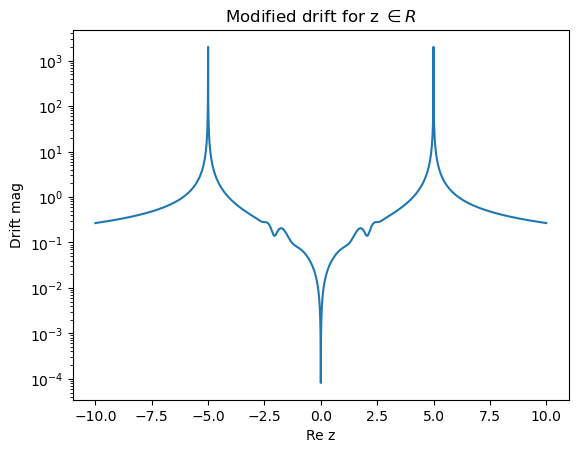

In [24]:
x = np.linspace(-10, 10, 10000)

plt.plot(x, np.abs(drift_mod_func(x, sigma, 1, pullback, phi_singular)))

plt.yscale('log')
plt.title(rf"Modified drift for z $\in R$")
plt.xlabel('Re z')
plt.ylabel('Drift mag')

Text(0.5, 1.0, 'Modified drift for large z $\\in R$')

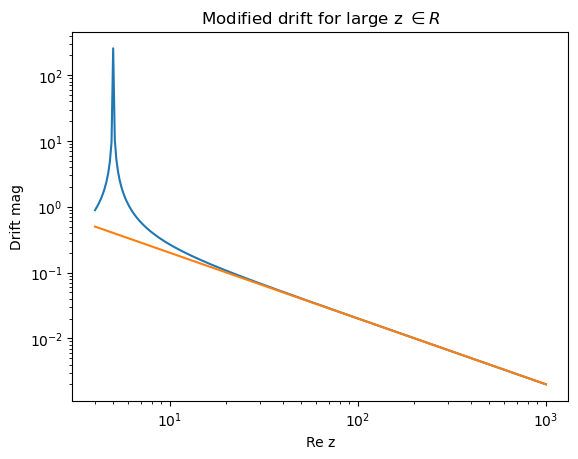

In [30]:
x = np.linspace(4, 1000, 10000)

plt.plot(x, np.abs(drift_mod_func(x, sigma, 1, pullback, phi_singular)))
approx = lambda x: -2/x

plt.plot(x, np.abs(np.real(approx(x))))
plt.xlabel("Re z")
plt.ylabel("Drift mag")
plt.xscale('log')
plt.yscale('log')
plt.title(rf"Modified drift for large z $\in R$")

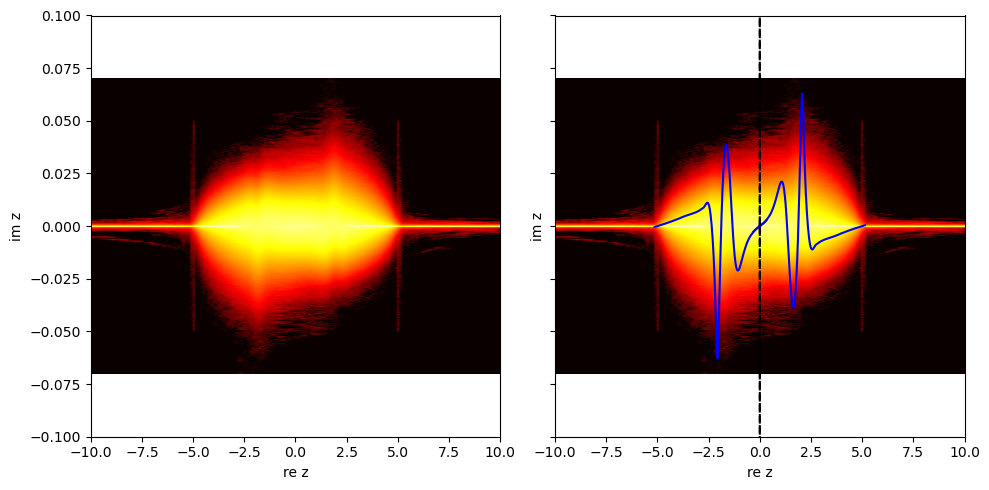

singular: 5
pullback: 120
sigma: (-3.5355339059327373+3.5355339059327378j)
lamb: 1


In [26]:
import matplotlib.pyplot as plt
fig1, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)


# fig1.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing between subplots

# for idx, (hist, sigma, ax) in enumerate(zip(histograms, sigma_vals, ax)):
sigma = sigma_vals[0]
hist = histograms[0]
label = rf"$Re (\sigma)={{{np.round(sigma.real, 2)}}} \, Im (\sigma)={{{np.round(sigma.imag, 2)}}}$"
xedg = edges_x[0]
yedg = edges_y[0]

# Plot the heatmap
ax[0].imshow(
    np.log10(hist+1).T,
    extent=[xedg[0], xedg[-1], yedg[0], yedg[-1]],
    origin='lower',
    cmap='hot',
    aspect='auto',
    )

ax[1].imshow(
    np.log10(hist+1).T,
    extent=[xedg[0], xedg[-1], yedg[0], yedg[-1]],
    origin='lower',
    cmap='hot',
    aspect='auto',
    )

stable, unstable = solve_floweq(lambda t, z: flow_equation_stable(t, z, sigma, interaction, pullback, phi_singular), 
                                lambda t, z: flow_equation_unstable(t, z, sigma, interaction, pullback, phi_singular), 
                                crit_point=0, t_span=(0, 100.2))

for init_data in stable:
    ax[1].plot(init_data.real, init_data.imag, color = 'blue', ls = '-')

for init_data in unstable:
    ax[1].plot(init_data.real, init_data.imag, color = 'black', ls = '--')

ax[1].set_xlim(-10, 10)
ax[1].set_ylim(-.1,.1)

ax[0].set_xlabel("re z")
ax[1].set_xlabel("re z")

ax[0].set_ylabel("im z")
ax[1].set_ylabel("im z")

plt.tight_layout()
plt.show()
print(f"singular: {phi_singular}")
print(f"pullback: {pullback}")
print(f"sigma: {sigma}")
print(f"lamb: {interaction}")

/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_44416/3398029068.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes1.legend()


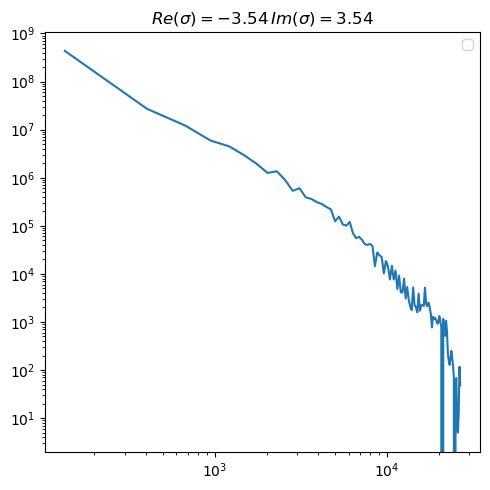

In [16]:

import matplotlib.pyplot as plt
fig1, axes1 = plt.subplots(1, figsize=(5, 5), sharex=True, sharey=True)
fig1.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing between subplots

for idx, (hist, sigma) in enumerate(zip(histograms, sigma_vals)):
    label = rf"$Re (\sigma)={{{np.round(sigma.real, 2)}}} \, Im (\sigma)={{{np.round(sigma.imag, 2)}}}$"
    xedg = edges_x[idx]
    yedg = edges_y[idx]
    bins = len(xedg)-1
    x_centers = (xedg[:-1] + xedg[1:]) / 2
    y_centers = (yedg[:-1] + yedg[1:]) / 2

    X, Y = np.meshgrid(x_centers, y_centers)
    Z = X + 1j * Y  # Complex coordinates of bin centers

    # Compute drift and its absolute value
    drift = sigma * Z + 1 * Z**3
    abs_drift = np.abs(drift)

    # Flatten arrays for re-binning
    abs_drift_flat = abs_drift.flatten()
    hist_flat = hist.flatten()

    # Define bins for the new histogram (you can adjust bin range and size)
    abs_drift_bins = np.linspace(0, np.max(abs_drift), 100)
    drift_hist, drift_edges = np.histogram(abs_drift_flat, bins=abs_drift_bins, weights=hist_flat)
    drift_centers = (drift_edges[:-1] + drift_edges[1:]) / 2

    axes1.plot(drift_centers, drift_hist)
    axes1.set_title(label)

    axes1.set_yscale('log')
    axes1.set_xscale('log')
axes1.legend()

plt.tight_layout()
plt.show()

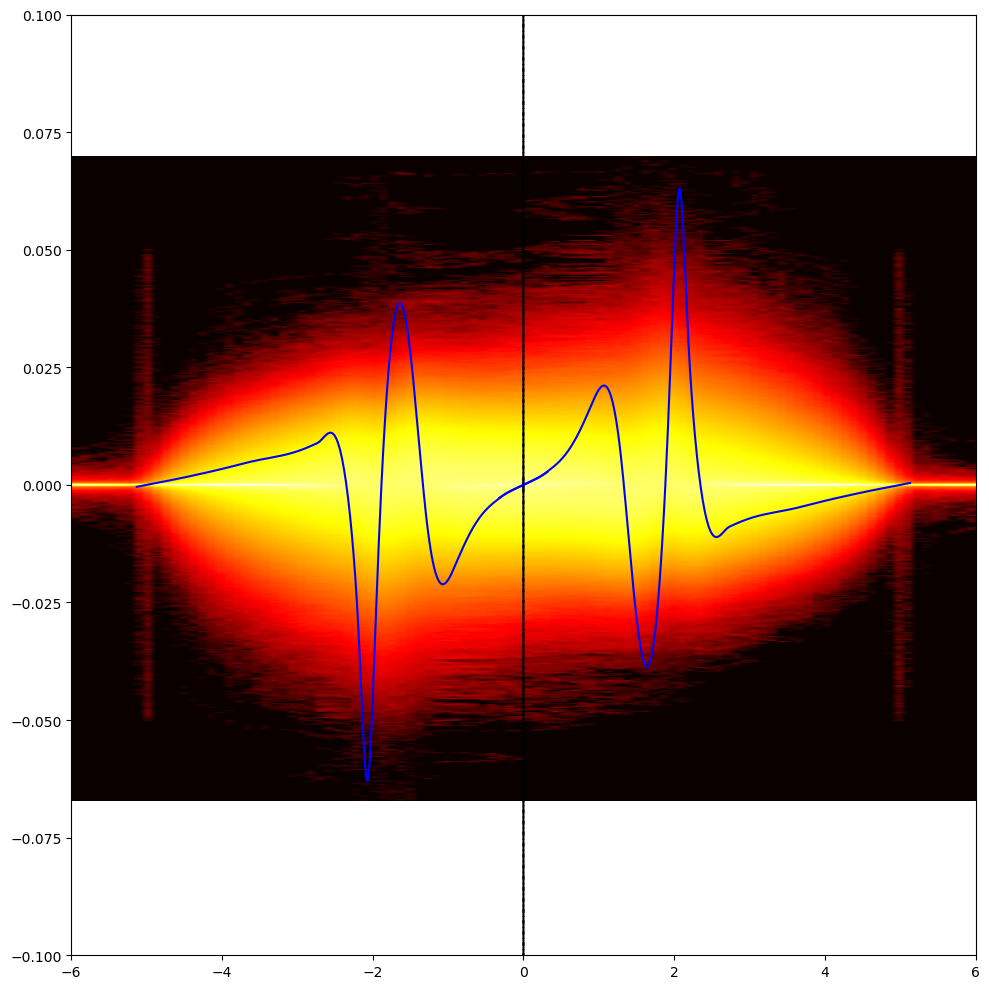

singular: 5
pullback: 120
sigma: (-3.5355339059327373+3.5355339059327378j)
lamb: 1


In [79]:
import matplotlib.pyplot as plt
fig1, ax = plt.subplots(1, figsize=(10, 10), sharex=True, sharey=True)
ax = np.array([ax])


# fig1.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing between subplots

# for idx, (hist, sigma, ax) in enumerate(zip(histograms, sigma_vals, ax)):
for idx, (axes1, hm, sigma) in enumerate(zip(ax, histograms, sigma_vals)):
    label = rf"$Re (\sigma)={{{np.round(sigma.real, 2)}}} \, Im (\sigma)={{{np.round(sigma.imag, 2)}}}$"
    xedg = edges_x[idx]
    yedg = edges_y[idx]

    # Plot the heatmap
    axes1.imshow(
        np.log10(hm+1).T,
        extent=[xedg[0], xedg[-1], yedg[0], yedg[-1]],
        origin='lower',
        cmap='hot',
        aspect='auto',
    )
    
    stable, unstable = solve_floweq(lambda t, z: flow_equation_stable(t, z, sigma, interaction, pullback, phi_singular), 
                                    lambda t, z: flow_equation_unstable(t, z, sigma, interaction, pullback, phi_singular), 
                                    crit_point=0, t_span=(0, 100.2))

    for init_data in stable:
        axes1.plot(init_data.real, init_data.imag, color = 'blue', ls = '-')
        

    for init_data in unstable:
        axes1.plot(init_data.real, init_data.imag, color = 'black', ls = '--')

    # ax.set_title(label)
    # thimble_plot(drift=drift_mod_func, flow_equation=flow_equation, phi_singular = phi_singular, sigma_phase=np.angle(sigma), sigma_abs=4, t_span=(0,14.2), x_range = (-20, 20), y_range=(-3, 3), pullback=pullback, ax=ax)

    # axes1.set_ylim(-0.1, 0.1)
    axes1.set_xlim(-6, 6)
    axes1.set_ylim(-0.1, 0.1)

plt.tight_layout()
plt.show()
print(f"singular: {phi_singular}")
print(f"pullback: {pullback}")
print(f"sigma: {sigma}")
print(f"lamb: {interaction}")

/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_37832/477227541.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes1.legend()


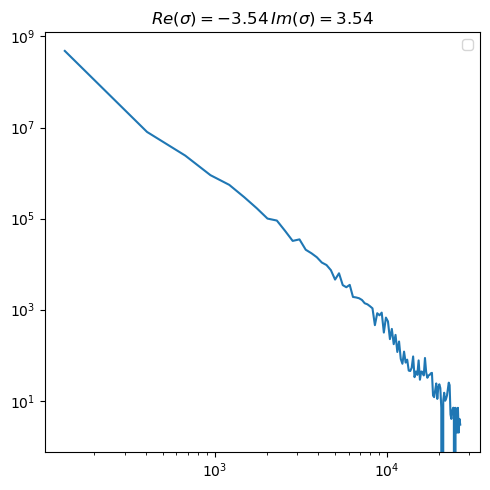

In [100]:

import matplotlib.pyplot as plt
fig1, axes1 = plt.subplots(1, figsize=(5, 5), sharex=True, sharey=True)
fig1.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing between subplots

for idx, (hist, sigma) in enumerate(zip(histograms, sigma_vals)):
# for idx, (axes1, hm, sigma) in enumerate(zip(axes1, heatmaps, sigma_vals)):
    label = rf"$Re (\sigma)={{{np.round(sigma.real, 2)}}} \, Im (\sigma)={{{np.round(sigma.imag, 2)}}}$"
    xedg = edges_x[idx]
    yedg = edges_y[idx]
    bins = len(xedg)-1
    x_centers = (xedg[:-1] + xedg[1:]) / 2
    y_centers = (yedg[:-1] + yedg[1:]) / 2

    X, Y = np.meshgrid(x_centers, y_centers)
    Z = X + 1j * Y  # Complex coordinates of bin centers

    # Compute drift and its absolute value
    drift = sigma * Z + 1 * Z**3
    abs_drift = np.abs(drift)

    # Flatten arrays for re-binning
    abs_drift_flat = abs_drift.flatten()
    hist_flat = hist.flatten()

    # Define bins for the new histogram (you can adjust bin range and size)
    abs_drift_bins = np.linspace(0, np.max(abs_drift), 100)
    drift_hist, drift_edges = np.histogram(abs_drift_flat, bins=abs_drift_bins, weights=hist_flat)
    drift_centers = (drift_edges[:-1] + drift_edges[1:]) / 2

    axes1.plot(drift_centers, drift_hist)
    axes1.set_title(label)
    # axes1.set_xlim(-10,10)
    # axes1.set_ylim(-10,10)
    axes1.set_yscale('log')
    axes1.set_xscale('log')
axes1.legend()

plt.tight_layout()
plt.show()

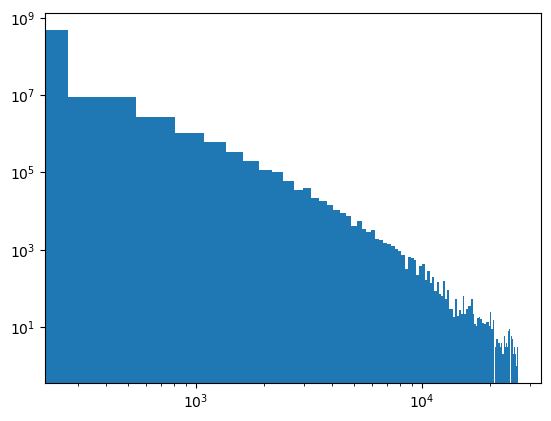

In [125]:
# Compute bin centers
X, Y = np.meshgrid(x_centers, y_centers)
Z = X + 1j * Y  # Complex coordinates of bin centers

# Compute drift and its absolute value
drift = sigma * Z + 1 * Z**3
abs_drift = np.abs(drift)

# Flatten arrays for re-binning
abs_drift_flat = abs_drift.flatten()
hist_flat = hist.flatten()

# Define bins for the new histogram (you can adjust bin range and size)
abs_drift_bins = np.linspace(0, np.max(abs_drift), 100)

# Compute histogram of |drift|
plt.hist(abs_drift_flat, bins=abs_drift_bins, weights=hist_flat)
plt.xscale('log')
plt.yscale('log')
# Output results

/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_59965/2174554414.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes1.legend()


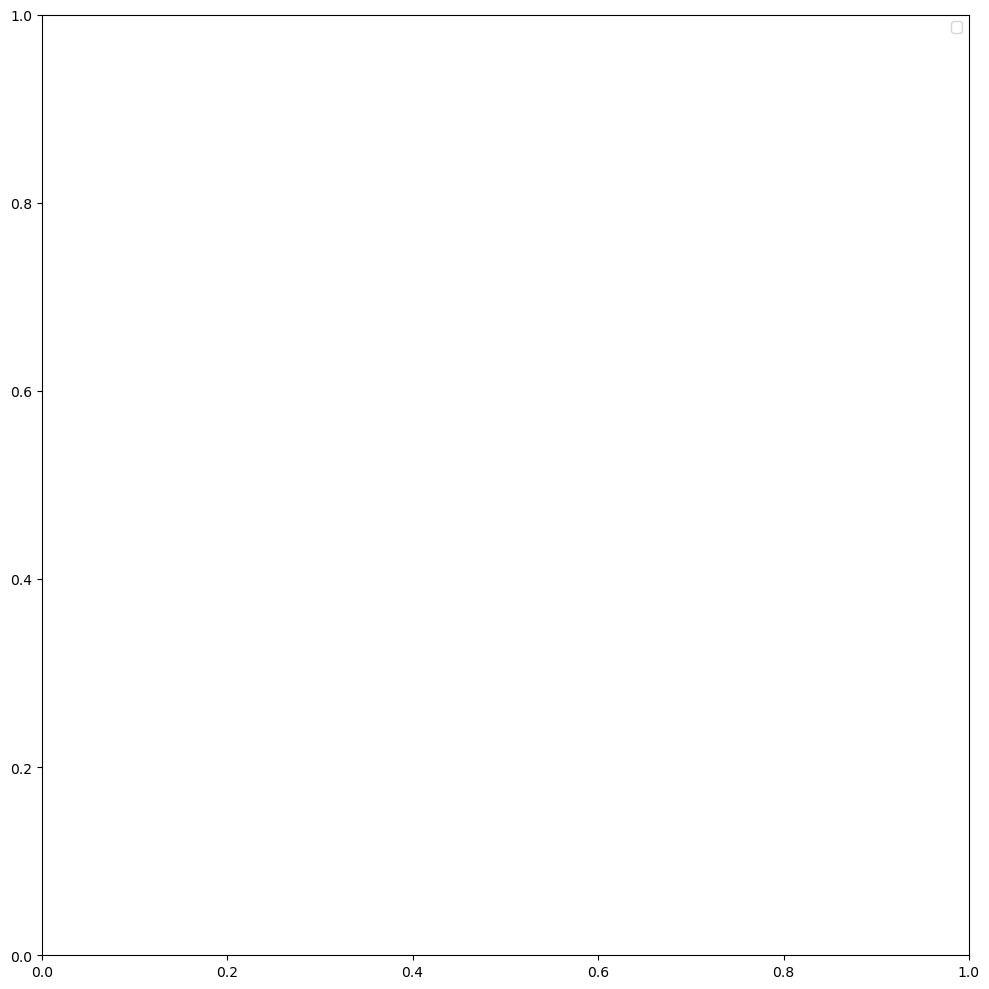

In [92]:

import matplotlib.pyplot as plt
fig1, axes1 = plt.subplots(1, figsize=(10, 10), sharex=True, sharey=True)
fig1.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing between subplots

for idx, (hist, sigma) in enumerate(zip(histograms, sigma_vals)):
    if idx>6:
    # for idx, (axes1, hm, sigma) in enumerate(zip(axes1, heatmaps, sigma_vals)):
        label = rf"$Re (\sigma)={{{np.round(sigma.real, 2)}}} \, Im (\sigma)={{{np.round(sigma.imag, 2)}}}$"
        xedg = edges_x[idx]
        yedg = edges_y[idx]
        bins = len(xedg)-1
        x_centers = (xedg[:-1] + xedg[1:]) / 2
        y_centers = (yedg[:-1] + yedg[1:]) / 2

        x_mesh, y_mesh = np.meshgrid(x_centers, y_centers, indexing='ij')
        # Plot the heatmap

        axes1.set_title(label)
        # axes1.set_xlim(-10,10)
        # axes1.set_ylim(-10,10)
        axes1.set_yscale('log')
        axes1.set_xscale('log')
axes1.legend()

plt.tight_layout()
plt.show()

UFuncTypeError: ufunc 'absolute' did not contain a loop with signature matching types <class 'numpy.dtypes.StrDType'> -> None

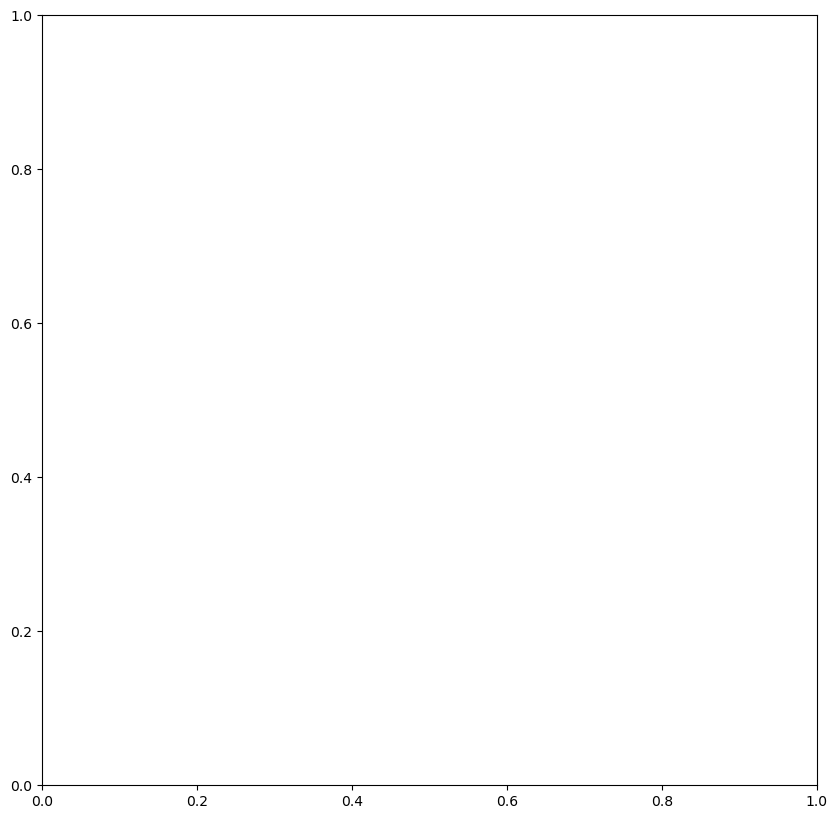

In [93]:

import matplotlib.pyplot as plt
fig1, axes1 = plt.subplots(1, figsize=(10, 10), sharex=True, sharey=True)
fig1.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing between subplots

for idx, (hist, sigma) in enumerate(zip(histograms, sigma_vals)):
    label = rf"$Re (\sigma)={{{np.round(sigma.real, 2)}}} \, Im (\sigma)={{{np.round(sigma.imag, 2)}}}$"
    magnitudes = np.abs(data)
    data = data[magnitudes<10*np.sqrt(2)]

    mags = np.abs(data)
    hist, xedges = np.histogram(mags, bins = 300, density=True)
    x_centers = (xedges[:-1] + xedges[1:]) / 2
    axes1.plot(x_centers, hist)
    
axes1.set_yscale('log')
axes1.set_xscale('log')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'CL process distribution in complex plane')

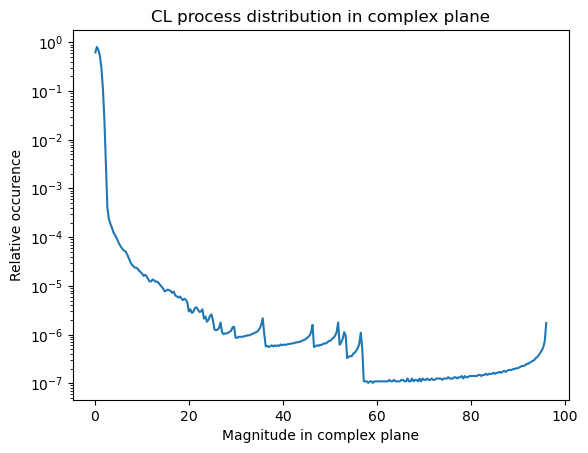

In [24]:
mags = np.abs(data_full)
hist, xedges = np.histogram(mags, bins = 300, density=True)
x_centers = (xedges[:-1] + xedges[1:]) / 2
plt.plot(x_centers, hist)
plt.yscale('log')
plt.xlabel("Magnitude in complex plane")
plt.ylabel("Relative occurence")
plt.title("CL process distribution in complex plane")

Text(0.5, 1.0, 'CL drift distribution in complex plane')

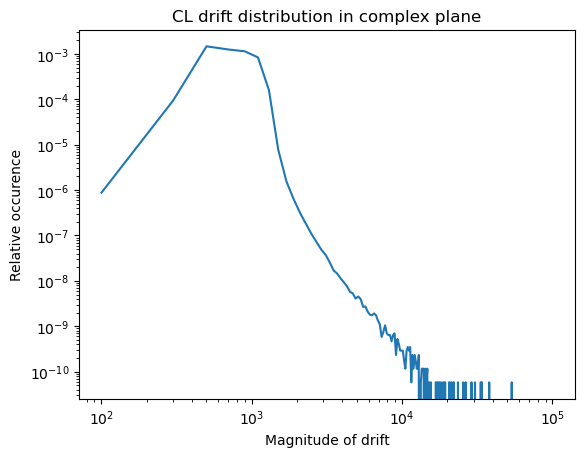

In [ ]:
bins = 500
idx = 2
hist = histograms[idx]
xedges = edges_x[idx]
yedges = edges_y[idx]

x_centers = (xedges[:-1] + xedges[1:]) / 2
y_centers = (yedges[:-1] + yedges[1:]) / 2
X, Y = np.meshgrid(x_centers, y_centers)
Z = X + 1j * Y  # Complex grid

U_values = abs_drift(Z, sigma=sigma, interaction=sim.interaction)
u_min, u_max, num_bins = U_values.min(), U_values.max(), bins
u_bins = np.linspace(u_min, u_max, bins)
u_centers = 0.5 * (u_bins[:-1] + u_bins[1:])  # Bin centers

U_values_flat = U_values.flatten()
heatmap_flat = hist.flatten()
hist, _ = np.histogram(U_values_flat, bins=u_bins, weights=heatmap_flat, density = True)

plt.plot(u_centers, hist)
plt.xscale('log')
plt.yscale('log')

plt.xlabel("Magnitude of drift")
plt.ylabel("Relative occurence")
plt.title("CL drift distribution in complex plane")


In [222]:
import numpy as np
from simulation.config import Config
from simulation.cl_simulation import ComplexLangevinSimulation
from src.obs_kernels import n_moment_kernel
from tqdm import tqdm
from simulation.gpu_handler import GPU_handler
from src.numba_target import use_cuda
import src.scal as scal
from sim_data.save_data import create_unique_file


steps = int(1e4)
trajs = int(1e4)
data = np.zeros((num, steps*trajs), dtype=scal.SCAL_TYPE)
for idx_sig, sigma in enumerate(sigma_vals):
    label = rf"$Re (\sigma)={{{np.round(sigma.real, 2)}}} \quad Im (\sigma)={{{np.round(sigma.imag, 2)}}}$"
    config = Config(dt = 1e-2, trajs = trajs, dims = [1], mass_real = sigma, interaction = interaction, ada_step = True)
    sim = ComplexLangevinSimulation(config)

    for idx, _ in enumerate(tqdm(range(steps))):
        sim.step()
        data[idx_sig, trajs*idx: trajs*(idx+1)] = sim.phi0
    sim.finish()
# data = (sim.trackers['1_moment'].history.flatten())
name = create_unique_file(data, directory="../sim_data")

100%|██████████| 10000/10000 [00:01<00:00, 6544.42it/s]


File saved: ../sim_data/temp_ac522b3e2b4e3aad8e941147111b8f4b.npy


In [ ]:
data_full = np.load("../sim_data/temp_ac522b3e2b4e3aad8e941147111b8f4b.npy")
data_full

array([[-0.28475943+0.j        ,  0.03490704+0.j        ,
        -0.10534583+0.j        , ..., -0.86335844+0.16792141j,
        -1.5336381 +0.17906499j,  1.0909132 -0.1356348j ]],
      dtype=complex64)

(-0.7078135342965217+0.7063993209698511j)


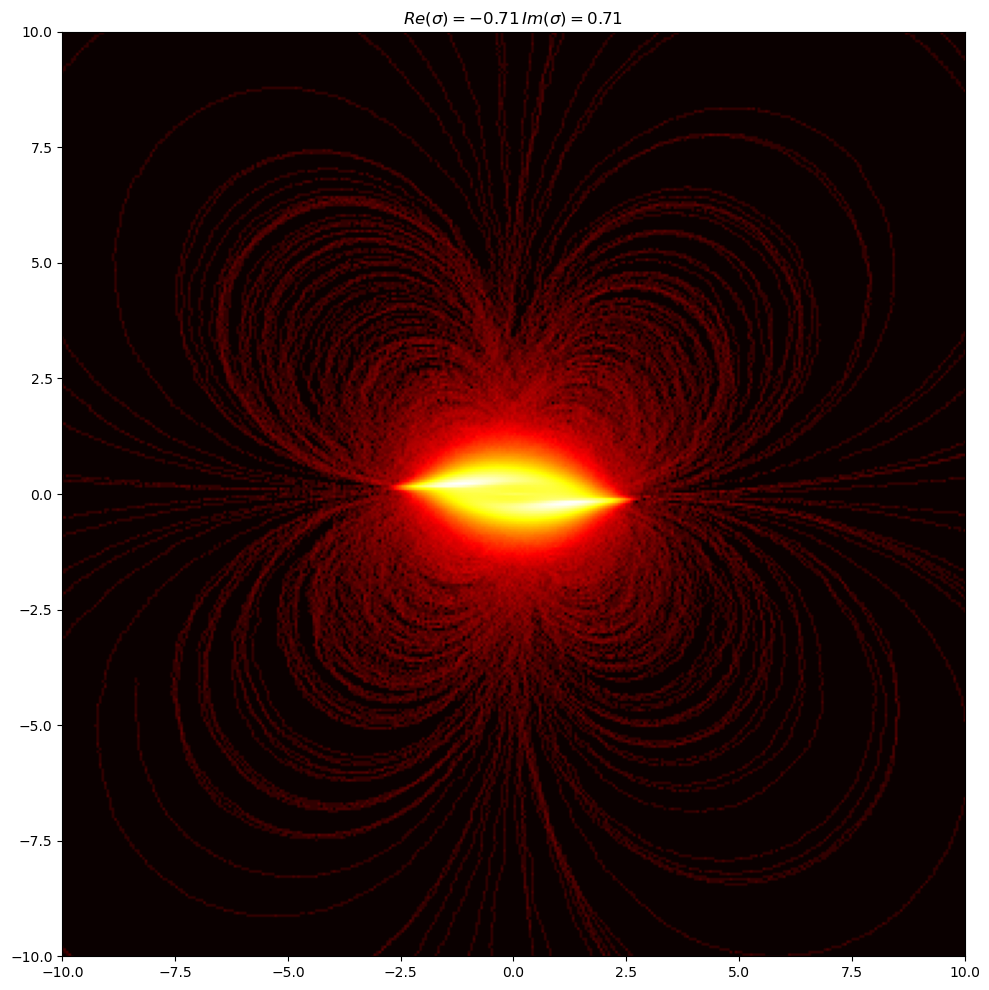

In [232]:

import matplotlib.pyplot as plt
fig1, axes1 = plt.subplots(int(np.sqrt(num)), int(np.sqrt(num)), figsize=(10, 10), sharex=True, sharey=True)
axes1 = np.array(axes1)
axes1 = axes1.flatten()
fig1.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing between subplots

for idx, (ax1, data, sigma) in enumerate(zip(axes1, data_full, sigma_vals)):
    print(sigma)
    label = rf"$Re (\sigma)={{{np.round(sigma.real, 2)}}} \, Im (\sigma)={{{np.round(sigma.imag, 2)}}}$"
    magnitudes = np.abs(data)
    data = data[magnitudes<10*np.sqrt(2)]

    real_parts, imag_parts = data.real, data.imag
    bins = 300
    heatmap, xedges, yedges = np.histogram2d(real_parts, imag_parts, bins=bins)
    
    # Plot the heatmap
    ax1.imshow(
        np.log10(heatmap+1).T,
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        origin='lower',
        cmap='hot',
        aspect='auto',
    )

    ax1.set_title(label)
    ax1.set_xlim(-10,10)
    ax1.set_ylim(-10,10)
    plt.tight_layout()
plt.show()

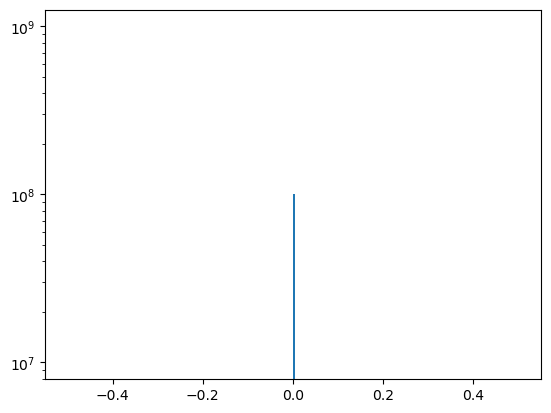

In [ ]:
data = data_full[0]
mags = np.abs(data)
plt.hist(mags, bins = 300)
# plt.xscale('log')
plt.yscale('log')

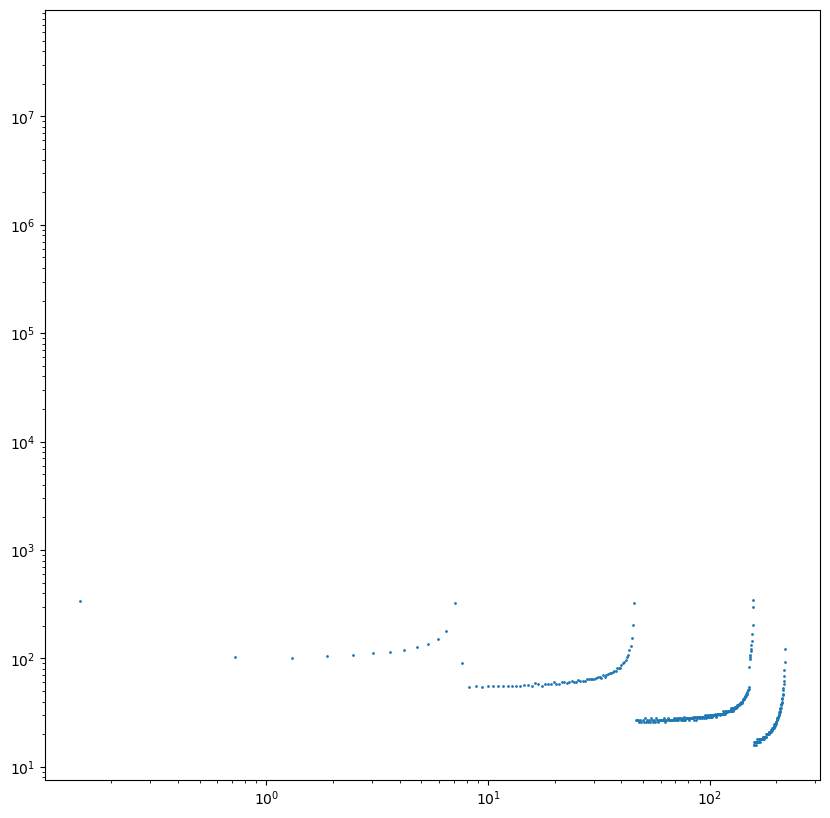

In [183]:

import matplotlib.pyplot as plt
fig1, axes1 = plt.subplots(int(np.sqrt(num)), int(np.sqrt(num)), figsize=(10, 10), sharex=True, sharey=True)
axes1 = np.array(axes1)

axes1 = axes1.flatten()
fig1.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing between subplots

for idx, (ax1, data, sigma) in enumerate(zip(axes1, data_full, sigma_vals)):
    label = rf"$Re (\sigma)={{{np.round(sigma.real, 2)}}} \, Im (\sigma)={{{np.round(sigma.imag, 2)}}}$"
    
    hist, x_edges = np.histogram(np.abs(data), bins=bins)
    bins = 500

    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(x_centers, y_centers)
    Z = X + 1j * Y  # Complex grid

    ax1.scatter(x_centers, hist, s = 1)
    # ax2.set_title(label)
    ax1.set_yscale('log')
    ax1.set_xscale('log')
plt.show()

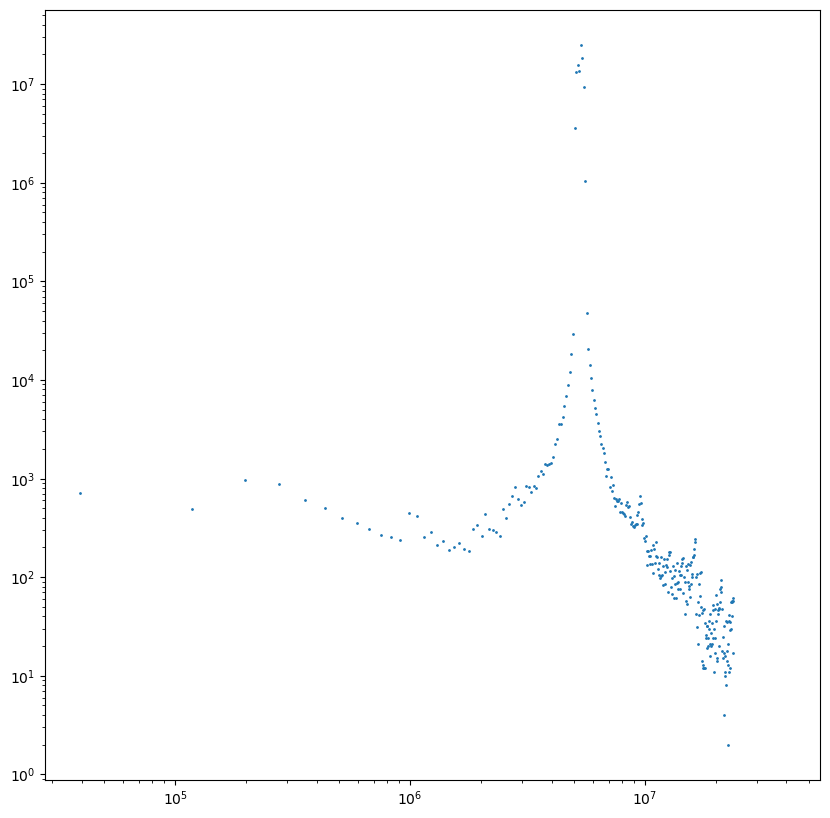

In [182]:

import matplotlib.pyplot as plt
fig1, axes1 = plt.subplots(int(np.sqrt(num)), int(np.sqrt(num)), figsize=(10, 10), sharex=True, sharey=True)
axes1 = np.array(axes1)

axes1 = axes1.flatten()
fig1.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing between subplots

for idx, (ax1, data, sigma) in enumerate(zip(axes1, data_full, sigma_vals)):
    label = rf"$Re (\sigma)={{{np.round(sigma.real, 2)}}} \, Im (\sigma)={{{np.round(sigma.imag, 2)}}}$"

    bins = 500
    heatmap, xedges, yedges = np.histogram2d(data.real, data.imag, bins=bins)

    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(x_centers, y_centers)
    Z = X + 1j * Y  # Complex grid

    U_values = abs_drift(Z, sigma=sigma, interaction=sim.interaction)
    u_min, u_max, num_bins = U_values.min(), U_values.max(), bins
    u_bins = np.linspace(u_min, u_max, bins)
    u_centers = 0.5 * (u_bins[:-1] + u_bins[1:])  # Bin centers

    U_values_flat = U_values.flatten()
    heatmap_flat = heatmap.flatten()
    hist, _ = np.histogram(U_values_flat, bins=u_bins, weights=heatmap_flat)
    ax1.scatter(u_centers, hist, s = 1)
    # ax2.set_title(label)
    ax1.set_yscale('log')
    ax1.set_xscale('log')
plt.show()

 12%|█▏        | 575/5000 [00:00<00:00, 5231.27it/s]


KeyboardInterrupt: 

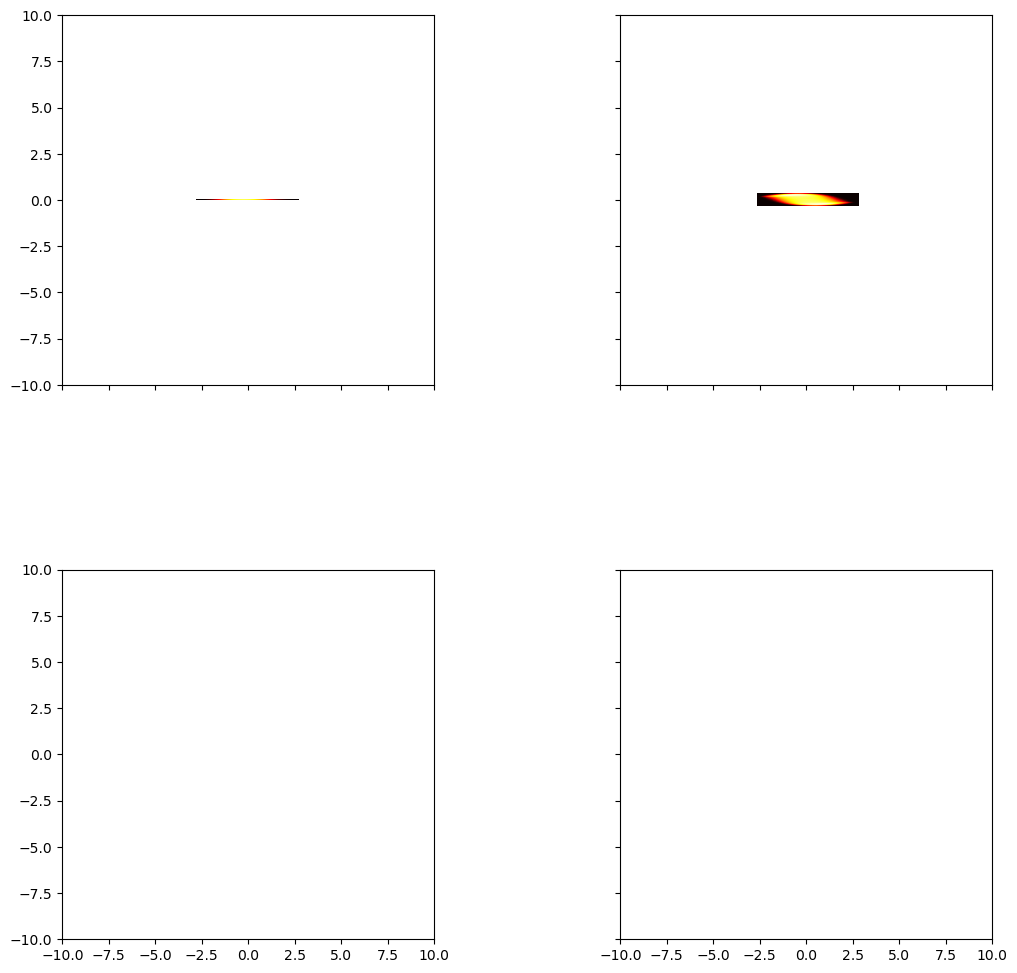

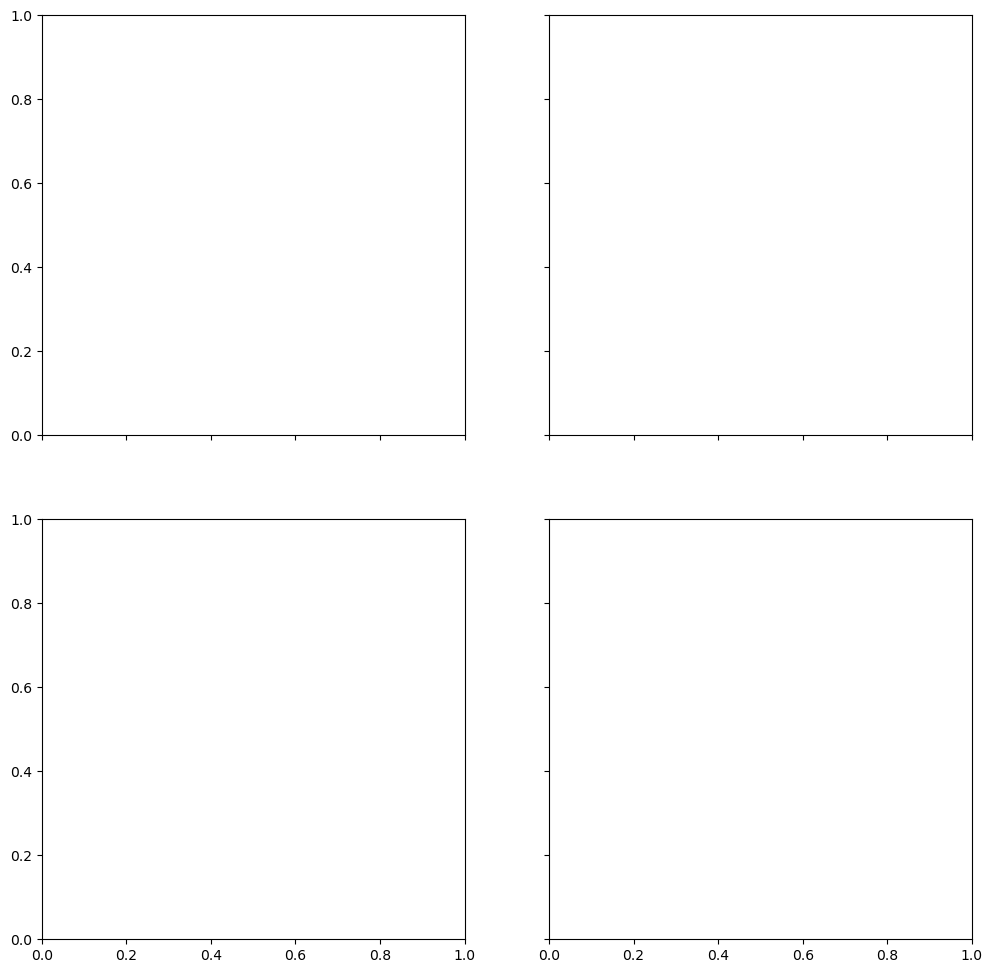

In [7]:

import matplotlib.pyplot as plt
fig1, ax1es1 = plt.subplots(int(np.sqrt(num)), int(np.sqrt(num)), figsize=(12, 12), sharex=True, sharey=True)
ax1es1 = ax1es1.flatten()
fig1.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing between subplots

ig1, axes2 = plt.subplots(int(np.sqrt(num)), int(np.sqrt(num)), figsize=(12, 12), sharex=True, sharey=True)
axes2 = axes2.flatten()
fig1.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing between subplots


import numpy as np
from simulation.config import Config
from simulation.cl_simulation import ComplexLangevinSimulation
from src.obs_kernels import n_moment_kernel
from tqdm import tqdm
from simulation.gpu_handler import GPU_handler
from src.numba_target import use_cuda

for idx, (ax1, ax2, sigma) in enumerate(zip(ax1es1, axes2, (sigma_vals))):
    label = rf"$Re (\sigma)={{{np.round(sigma.real, 2)}}} \quad Im (\sigma)={{{np.round(sigma.imag, 2)}}}$"

    config = Config(dt = 1e-2, trajs = int(5e3), dims = [1], mass_real = sigma, interaction = interaction, ada_step = True)
    sim = ComplexLangevinSimulation(config)
    gpu_handler = GPU_handler(sim)
    if use_cuda: gpu_handler.to_device()
    sim.register_observable('1_moment', obs_kernel=n_moment_kernel, const_param={'order': 1}, langevin_history=True, thermal_time=0, auto_corr=0.0)

    # for _ in tqdm(range(int(2e4-1))):
    for _ in tqdm(range(int(5e3))):
        sim.step()
        for name, tr in sim.trackers.items():
            tr.mark_equilibrated_trajs()
            tr.compute()
    sim.finish()
    if use_cuda: gpu_handler.to_host()
    
    data = (sim.trackers['1_moment'].history.flatten())
    
    magnitudes = np.abs(data)
    data = data[magnitudes<20]
    # da = np.append([art_dp, -art_dp], da)
    real_parts, imag_parts = data.real, data.imag
    bins = 300
    heatmap, xedges, yedges = np.histogram2d(real_parts, imag_parts, bins=bins)

    # Plot the heatmap
    ax1.imshow(
        np.log10(heatmap+1).T,
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        origin='lower',
        cmap='hot',
        aspect='auto',
    )
    # ax1.set_title(label)

    ax1.set_xlim(-10,10)
    ax1.set_ylim(-10,10)

    # x_centers = (xedges[:-1] + xedges[1:]) / 2
    # y_centers = (yedges[:-1] + yedges[1:]) / 2
    # X, Y = np.meshgrid(x_centers, y_centers)
    # Z = X + 1j * Y  # Complex grid

    # U_values = abs_drift(Z, mass=sigma, interaction=sim.interaction)
    # u_min, u_max, num_bins = U_values.min(), U_values.max(), 300
    # u_bins = np.linspace(u_min, u_max, bins)
    # u_centers = 0.5 * (u_bins[:-1] + u_bins[1:])  # Bin centers

    # U_values_flat = U_values.flatten()
    # heatmap_flat = heatmap.flatten()
    # hist, _ = np.histogram(U_values_flat.ravel(), bins=u_bins, weights=heatmap_flat.ravel())
    # ax2.scatter(u_centers, hist, s = 1)

    # # label = rf"$|\sigma|={{{sigma_abs}}} \quad arg(\sigma) = \frac{{{idx}}}{{{num}}} 2\pi$"

    # ax2.set_title(label)
    # ax2.set_yscale('log')
    # ax2.set_xscale('log')
    # print('Done')
    # plt.tight_layout()
plt.show()

100%|██████████| 10000/10000 [00:01<00:00, 6335.35it/s]


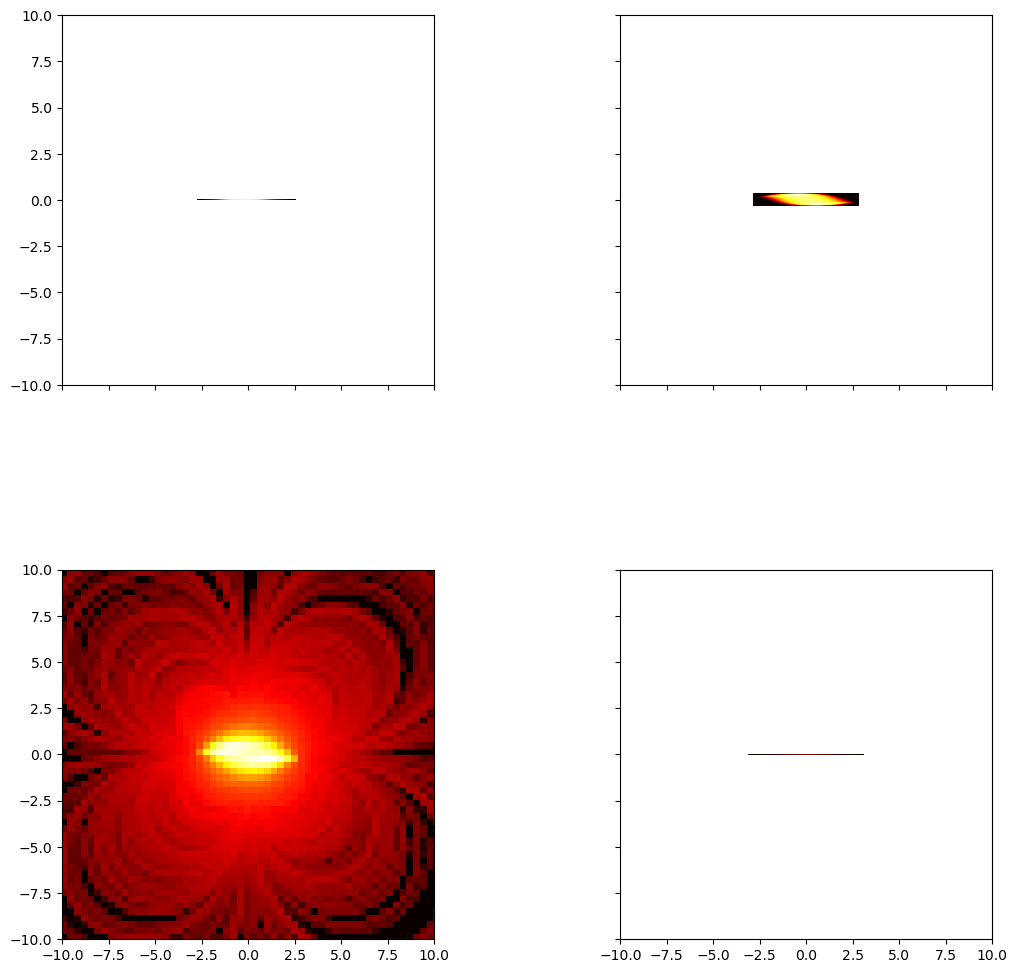

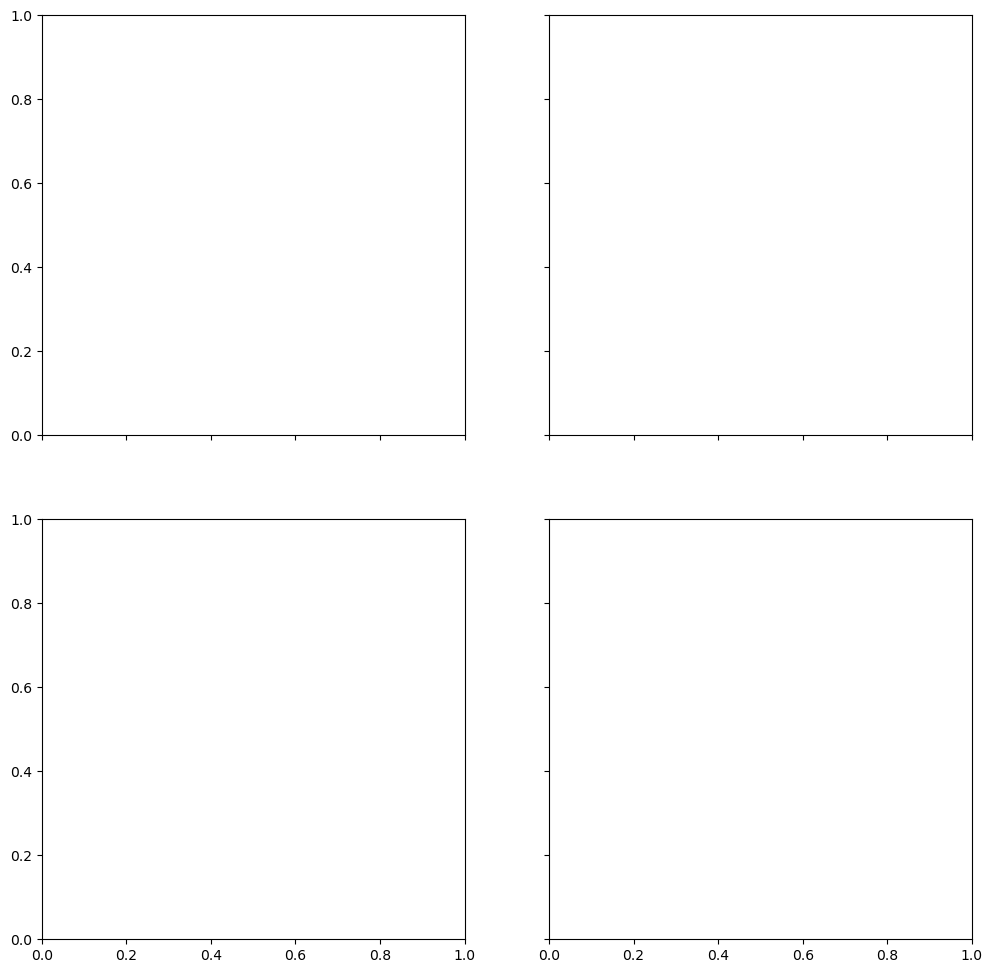

In [9]:

import matplotlib.pyplot as plt
fig1, ax1es1 = plt.subplots(int(np.sqrt(num)), int(np.sqrt(num)), figsize=(12, 12), sharex=True, sharey=True)
ax1es1 = ax1es1.flatten()
fig1.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing between subplots

ig1, axes2 = plt.subplots(int(np.sqrt(num)), int(np.sqrt(num)), figsize=(12, 12), sharex=True, sharey=True)
axes2 = axes2.flatten()
fig1.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing between subplots

import numpy as np
from simulation.config import Config
from simulation.cl_simulation import ComplexLangevinSimulation
from src.obs_kernels import n_moment_kernel
from tqdm import tqdm
from simulation.gpu_handler import GPU_handler
from src.numba_target import use_cuda

from src.utils import quadratic_modified_density_drift_kernel
import src.scal as scal

for idx, (ax1, ax2, sigma) in enumerate(zip(ax1es1, axes2, (sigma_vals))):
    label = rf"$Re (\sigma)={{{np.round(sigma.real, 2)}}} \quad Im (\sigma)={{{np.round(sigma.imag, 2)}}}$"
    steps = int(1e4)
    trajs = int(1e4)

    config = Config(dt = 1e-2, trajs = trajs, dims = [1], mass_real = sigma, interaction = interaction, ada_step = True)#, drift_kernel=quadratic_modified_density_drift_kernel)
    sim = ComplexLangevinSimulation(config)
    # gpu_handler = GPU_handler(sim)
    # if use_cuda: gpu_handler.to_device()
    sim.register_observable('1_moment', obs_kernel=n_moment_kernel, const_param={'order': 1}, langevin_history=True, thermal_time=0, auto_corr=0.0)

    # for _ in tqdm(range(int(2e4-1))):
    data = np.zeros(steps*trajs, dtype=scal.SCAL_TYPE)
    for idx, _ in enumerate(tqdm(range(steps))):
        sim.step()
        for name, tr in sim.trackers.items():
            tr.mark_equilibrated_trajs()
            tr.compute()
        data[idx*trajs:idx*trajs+trajs] = sim.phi0
    sim.finish()
    # print(data)
    # # Create 2D histogram
    # plt.figure(figsize=(8, 6))
    # plt.hist2d(datapoints.real, datapoints.imag, bins=100, cmap='viridis')
    # plt.colorbar(label='Counts')
    # plt.xlabel('Real Part')
    # plt.ylabel('Imaginary Part')
    # plt.title('Histogram of Complex Data Points in the Complex Plane')
    # plt.show()

    
    magnitudes = np.abs(data)
    # data = data[magnitudes<20]
    # da = np.append([art_dp, -art_dp], da)
    real_parts, imag_parts = data.real, data.imag
    bins = 300
    heatmap, xedges, yedges = np.histogram2d(real_parts, imag_parts, bins=bins)

    # Plot the heatmap
    ax1.imshow(
        np.log10(heatmap+1).T,
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        origin='lower',
        cmap='hot',
        aspect='auto',
    )
    ax1.set_xlim(-10,10)
    ax1.set_ylim(-10,10)
    # plt.show()
#     ax1.set_title(label)

#     ax1.set_xlim(-11, 11)
#     ax1.set_ylim(-1, 1)

#     x_centers = (xedges[:-1] + xedges[1:]) / 2
#     y_centers = (yedges[:-1] + yedges[1:]) / 2
#     X, Y = np.meshgrid(x_centers, y_centers)
#     Z = X + 1j * Y  # Complex grid

#     U_values = abs_mod_drift(Z, mass=sigma, interaction=sim.interaction)
#     u_min, u_max, num_bins = U_values.min(), U_values.max(), 300
#     u_bins = np.linspace(u_min, u_max, bins)
#     u_centers = 0.5 * (u_bins[:-1] + u_bins[1:])  # Bin centers

#     U_values_flat = U_values.flatten()
#     heatmap_flat = heatmap.flatten()
#     hist, _ = np.histogram(U_values_flat.ravel(), bins=u_bins, weights=heatmap_flat.ravel())
#     ax2.scatter(u_centers, hist, s = 1)

#     # label = rf"$|\sigma|={{{sigma_abs}}} \quad arg(\sigma) = \frac{{{idx}}}{{{num}}} 2\pi$"

#     ax2.set_title(label)
#     ax2.set_yscale('log')
#     ax2.set_xscale('log')
#     print('Done')
#     plt.tight_layout()
plt.show()

100%|██████████| 5000/5000 [00:01<00:00, 4439.66it/s]


Done


100%|██████████| 5000/5000 [00:01<00:00, 4250.97it/s]


Done


100%|██████████| 5000/5000 [00:01<00:00, 4190.45it/s]


...

Done


100%|██████████| 5000/5000 [00:01<00:00, 4320.89it/s]


Done


100%|██████████| 5000/5000 [00:01<00:00, 4463.50it/s]


Done


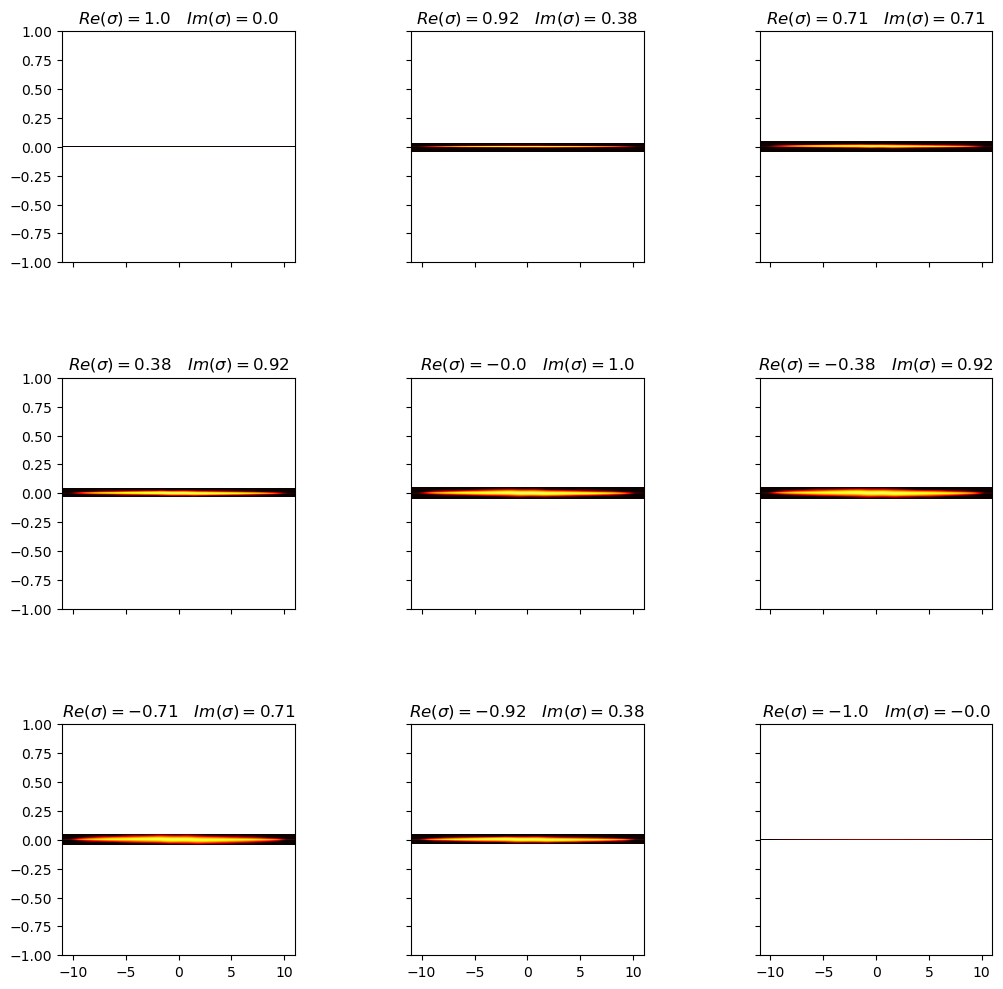

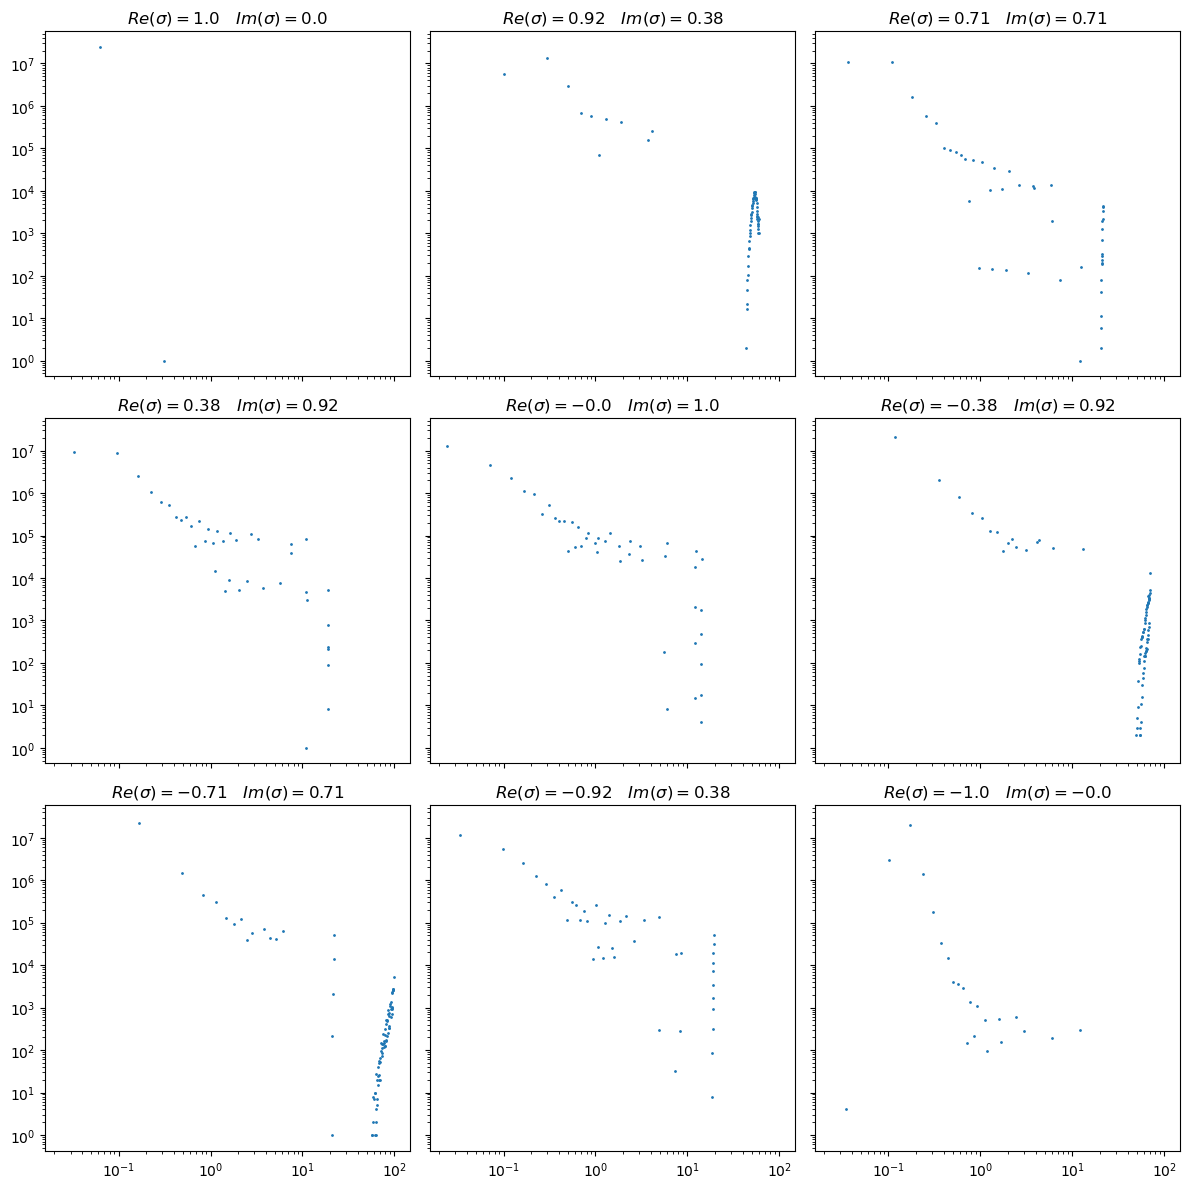

In [5]:

import matplotlib.pyplot as plt
fig1, ax1es1 = plt.subplots(int(np.sqrt(num)), int(np.sqrt(num)), figsize=(12, 12), sharex=True, sharey=True)
ax1es1 = ax1es1.flatten()
fig1.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing between subplots

ig1, axes2 = plt.subplots(int(np.sqrt(num)), int(np.sqrt(num)), figsize=(12, 12), sharex=True, sharey=True)
axes2 = axes2.flatten()
fig1.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing between subplots


import numpy as np
from simulation.config import Config
from simulation.cl_simulation import ComplexLangevinSimulation
from src.obs_kernels import n_moment_kernel
from tqdm import tqdm
from simulation.gpu_handler import GPU_handler
from src.numba_target import use_cuda

from src.utils import quadratic_modified_density_drift_kernel

for idx, (ax1, ax2, sigma) in enumerate(zip(ax1es1, axes2, (sigma_vals))):
    label = rf"$Re (\sigma)={{{np.round(sigma.real, 2)}}} \quad Im (\sigma)={{{np.round(sigma.imag, 2)}}}$"

    config = Config(dt = 1e-2, trajs = int(5e3), dims = [1], mass_real = sigma, interaction = interaction, ada_step = True, drift_kernel=quadratic_modified_density_drift_kernel)
    sim = ComplexLangevinSimulation(config)
    gpu_handler = GPU_handler(sim)
    if use_cuda: gpu_handler.to_device()
    sim.register_observable('1_moment', obs_kernel=n_moment_kernel, const_param={'order': 1}, langevin_history=True, thermal_time=0, auto_corr=0.0)

    # for _ in tqdm(range(int(2e4-1))):
    for _ in tqdm(range(int(5e3))):
        sim.step()
        for name, tr in sim.trackers.items():
            tr.mark_equilibrated_trajs()
            tr.compute()
    sim.finish()
    if use_cuda: gpu_handler.to_host()
    
    data = (sim.trackers['1_moment'].history.flatten())
    
    magnitudes = np.abs(data)
    # data = data[magnitudes<20]
    # da = np.append([art_dp, -art_dp], da)
    real_parts, imag_parts = data.real, data.imag
    bins = 300
    heatmap, xedges, yedges = np.histogram2d(real_parts, imag_parts, bins=bins)

    # Plot the heatmap
    ax1.imshow(
        np.log10(heatmap+1).T,
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        origin='lower',
        cmap='hot',
        aspect='auto',
    )
    ax1.set_title(label)

    ax1.set_xlim(-11, 11)
    ax1.set_ylim(-1, 1)

    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(x_centers, y_centers)
    Z = X + 1j * Y  # Complex grid

    U_values = abs_mod_drift(Z, mass=sigma, interaction=sim.interaction)
    u_min, u_max, num_bins = U_values.min(), U_values.max(), 300
    u_bins = np.linspace(u_min, u_max, bins)
    u_centers = 0.5 * (u_bins[:-1] + u_bins[1:])  # Bin centers

    U_values_flat = U_values.flatten()
    heatmap_flat = heatmap.flatten()
    hist, _ = np.histogram(U_values_flat.ravel(), bins=u_bins, weights=heatmap_flat.ravel())
    ax2.scatter(u_centers, hist, s = 1)

    # label = rf"$|\sigma|={{{sigma_abs}}} \quad arg(\sigma) = \frac{{{idx}}}{{{num}}} 2\pi$"

    ax2.set_title(label)
    ax2.set_yscale('log')
    ax2.set_xscale('log')
    print('Done')
    plt.tight_layout()
plt.show()